In [107]:
using Flux, CUDA, Statistics, ProgressMeter, Plots


In [108]:
# Brooks Corey relperm formula that we are trying to learn

# s = saturation (variable range 0.0, 1.0)
# n = Exponents for each phase (range from 1.0 to 6.0) set to constant 2
# sr = Residual saturations for each phase (set to 0.2)
# kwm = The maximum relative permeabilities (range from 0.0 to 1.0) set to constant 1.0
# sr_tot = Total residual saturation over all phases i.e. S_or + S_gr + S_wr. (range 0.0 to 1.0) should sr*number of phases

# the output should be between 0 and 1

function brooks_corey_relperm(s::T, n::Real, sr::Real, kwm::Real, sr_tot::Real) where T
    den = 1 - sr_tot
    sat = (s - sr) / den
    sat = clamp(sat, zero(T), one(T))
    return kwm*sat^n
end

brooks_corey_relperm (generic function with 1 method)

In [109]:
# Generate some data for training a model to represent BrooksCorey function
#training_sat = rand(Float32, 1000);                                    # 1×1000 Matrix{Float32} [0.0,1.0]
training_sat = collect(range(Float32(0), stop=Float32(1), length=10000))
rel_perm_analytical = Array{Float32, 1}(undef, 10000); # Creates a one-dimensional array of Float32 with 1000 elements


In [110]:
training_sat = reshape(training_sat, 1, :)
rel_perm_analytical = reshape(rel_perm_analytical, 1, :)

print(size(training_sat), "\n")
print(size(rel_perm_analytical))

(1, 10000)
(1, 10000)

In [111]:
for i in eachindex(training_sat)
    rel_perm_analytical[i] =  brooks_corey_relperm(training_sat[i], 2.0, 0.2, 1.0, 0.4)
end

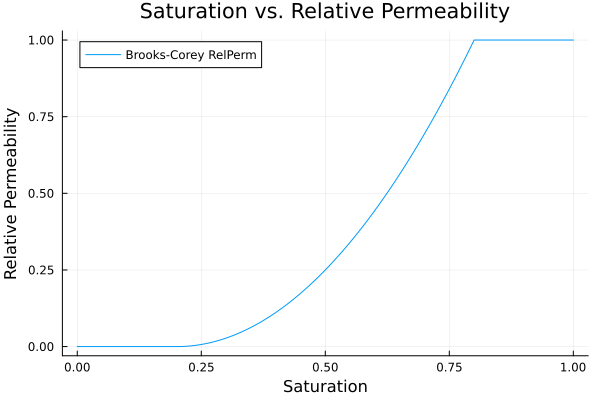

In [112]:
plot(vec(training_sat), vec(rel_perm_analytical), label="Brooks-Corey RelPerm", xlabel="Saturation", ylabel="Relative Permeability", title="Saturation vs. Relative Permeability")

In [113]:
# Define our model, a multi-layer perceptron with two hidden layers of size 100
model = Chain(
    Dense(1 => 100, relu; init=Flux.glorot_normal),   # activation function inside layer
    Dense(100 => 100, relu; init=Flux.glorot_normal),
    Dense(100 => 100, relu; init=Flux.glorot_normal),
    Dense(100 => 1; init=Flux.glorot_normal),
    relu) |> gpu        # move model to GPU, if available


Chain(
  Dense(1 => 100, relu),                # 200 parameters
  Dense(100 => 100, relu),              # 10_100 parameters
  Dense(100 => 100, relu),              # 10_100 parameters
  Dense(100 => 1),                      # 101 parameters
)                   # Total: 8 arrays, 20_501 parameters, 1.305 KiB.

In [114]:
# The model takes in the saturation with the shape (1xN)
rel_perm_predicted = model(training_sat |> gpu) |> cpu                                 # 1×1000 Matrix{Float32}
# The output of hte model is the relative Permeability with shape (1xN)

# To train the model, we use batches of 64 samples
loader = Flux.DataLoader((training_sat, rel_perm_analytical) |> gpu, batchsize=256, shuffle=true);

optim = Flux.setup(Flux.Adam(0.0001), model)  # will store optimiser momentum, etc.

(layers = ((weight = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[0.0; 0.0; … ; 0.0; 0.0;;], Float32[0.0; 0.0; … ; 0.0; 0.0;;], (0.9, 0.999))), bias = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999))), σ = ()), (weight = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], (0.9, 0.999))), bias = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999))), σ = ()), (weight =

In [115]:
# Training loop, using the whole data set 1000 times:
losses = []
@showprogress for epoch in 1:1000
    for (x, y) in loader
        loss, grads = Flux.withgradient(model) do m
            # Evaluate model and loss inside gradient context:
            y_hat = m(x)
            Flux.mse(y_hat, y)
        end
        Flux.update!(optim, model, grads[1])
        push!(losses, loss)  # logging, outside gradient context
    end
end

optim # parameters, momenta and output have all changed

Progress: 100%|█████████████████████████████████████████| Time: 0:00:28


(layers = ((weight = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[0.0; -7.14698f-6; … ; 0.0; 2.6251f-6;;], Float32[0.0; 5.9681f-8; … ; 0.0; 8.67064f-9;;], (6.0f-45, 4.16217f-18))), bias = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[0.0, -9.64697f-6, -2.30888f-6, 5.6755f-6, 0.0, 0.0, 0.0, 0.0, 0.0, -1.57505f-5  …  0.0, -5.60024f-6, 0.0, -9.60524f-6, 0.0, 0.0, -9.2068f-6, 0.0, 0.0, 3.45455f-6], Float32[0.0, 1.67254f-7, 3.26302f-9, 3.6419f-8, 0.0, 0.0, 0.0, 0.0, 0.0, 6.34349f-7  …  0.0, 4.93909f-8, 0.0, 1.06275f-7, 0.0, 0.0, 1.08511f-7, 0.0, 0.0, 2.17951f-8], (6.0f-45, 4.16217f-18))), σ = ()), (weight = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[0.0 1.07274f-8 … 0.0 -1.39955f-7; 0.0 0.0 … 0.0 6.0f-45; … ; 0.0 -3.65923f-8 … 0.0 -1.28818f-7; 0.0 0.0 … 0.0 0.0], Float32[0.0 1.33817f-11 … 0.0 8.3957f-10; 0.0 0.0 … 0.0 6.54599f-34; … ; 0.0 2.51561f-13 … 0.0 1.26489f-12; 0.0 0.0 … 0.0 0.0], (6.0f-45, 4.16217f-18))), bias = Leaf(Adam(0.0001, (0.9, 0.999), 1.0e-8), (Float32[-2.2

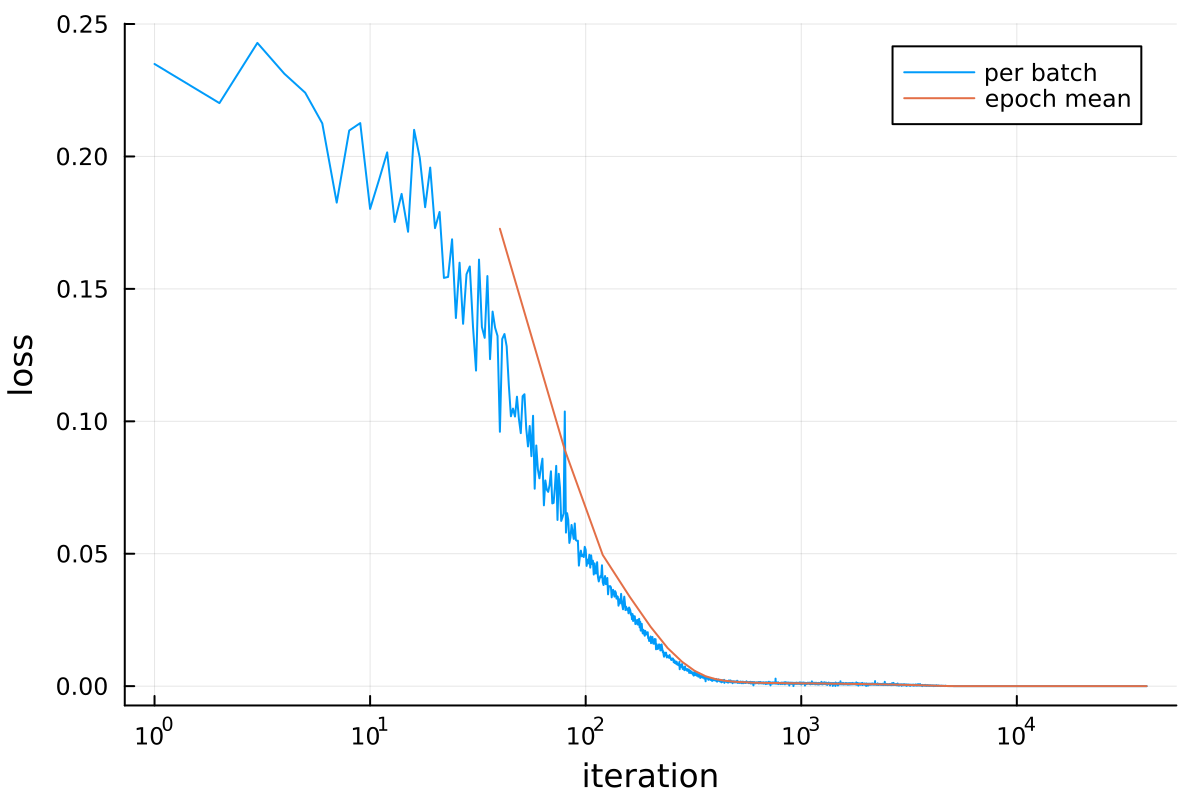

In [116]:
# plot loss function

plot(losses; xaxis=(:log10, "iteration"),
    yaxis="loss", label="per batch")
n = length(loader)
plot!(n:n:length(losses), mean.(Iterators.partition(losses, n)),
    label="epoch mean", dpi=200)

In [117]:
# Predict on the trained model
rel_perm_pred = model(training_sat |> gpu) |> cpu  

1×10000 Matrix{Float32}:
 -3.69269f-5  -3.2844f-5  -2.883f-5  …  0.999985  0.999985  0.999985

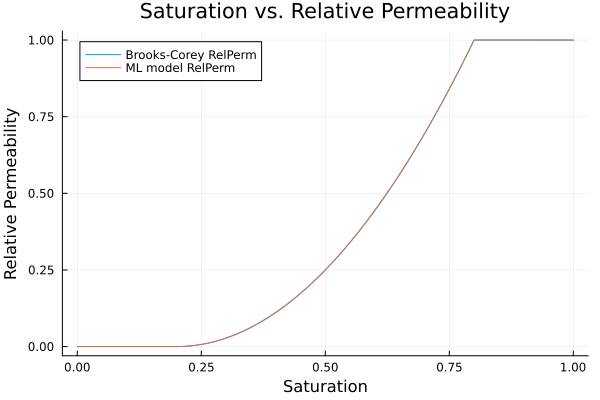

In [118]:
plot(vec(training_sat), vec(rel_perm_analytical), label="Brooks-Corey RelPerm", xlabel="Saturation", ylabel="Relative Permeability", title="Saturation vs. Relative Permeability")
plot!(vec(training_sat), vec(rel_perm_pred), label="ML model RelPerm", xlabel="Saturation", ylabel="Relative Permeability", title="Saturation vs. Relative Permeability")

In [119]:
using BSON: @save

@save "BrooksCoreyMLModel.bson" model


In [120]:
using Flux, BSON

BSON.@load "BrooksCoreyMLModel.bson" model

In [121]:
# test on random inputs, different to the training set

# Generate 1000 random numbers between 0 and 1
testing_sat = rand(Float32, 1000)
# sort for easier plotting
testing_sat = sort(testing_sat)
testing_sat = reshape(testing_sat, 1, :)

# Calculate analytical solution using Brooks Corey relperm
test_y = Array{Float32, 1}(undef, 1000)
test_y = reshape(test_y, 1, :)
for i in eachindex(testing_sat)
    test_y[i] = brooks_corey_relperm(testing_sat[i], 2.0, 0.2, 1.0, 0.4)
end

# Predict on the trained model
pred_y = model(testing_sat |> gpu) |> cpu

1×1000 Matrix{Float32}:
 -1.71345f-5  8.99844f-6  9.59821f-6  …  0.999985  0.999985  0.999985

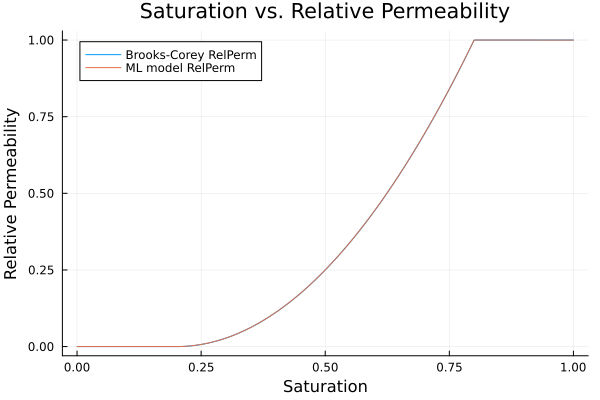

In [122]:
plot(vec(testing_sat), vec(test_y), label="Brooks-Corey RelPerm", xlabel="Saturation", ylabel="Relative Permeability", title="Saturation vs. Relative Permeability")
plot!(vec(testing_sat), vec(pred_y), label="ML model RelPerm", xlabel="Saturation", ylabel="Relative Permeability", title="Saturation vs. Relative Permeability")